Niki Bell and Madeleine Panter Final Project on Predictive Modeling of Maternal Health Risk Levels​

File created

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix as scatterplotmatrix
from seaborn import heatmap
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [3]:
#Displaying the data
df = pd.read_csv("Maternal Health Risk Data Set.csv")
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
df.shape

(1014, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [6]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

There are no missing values in this dataset

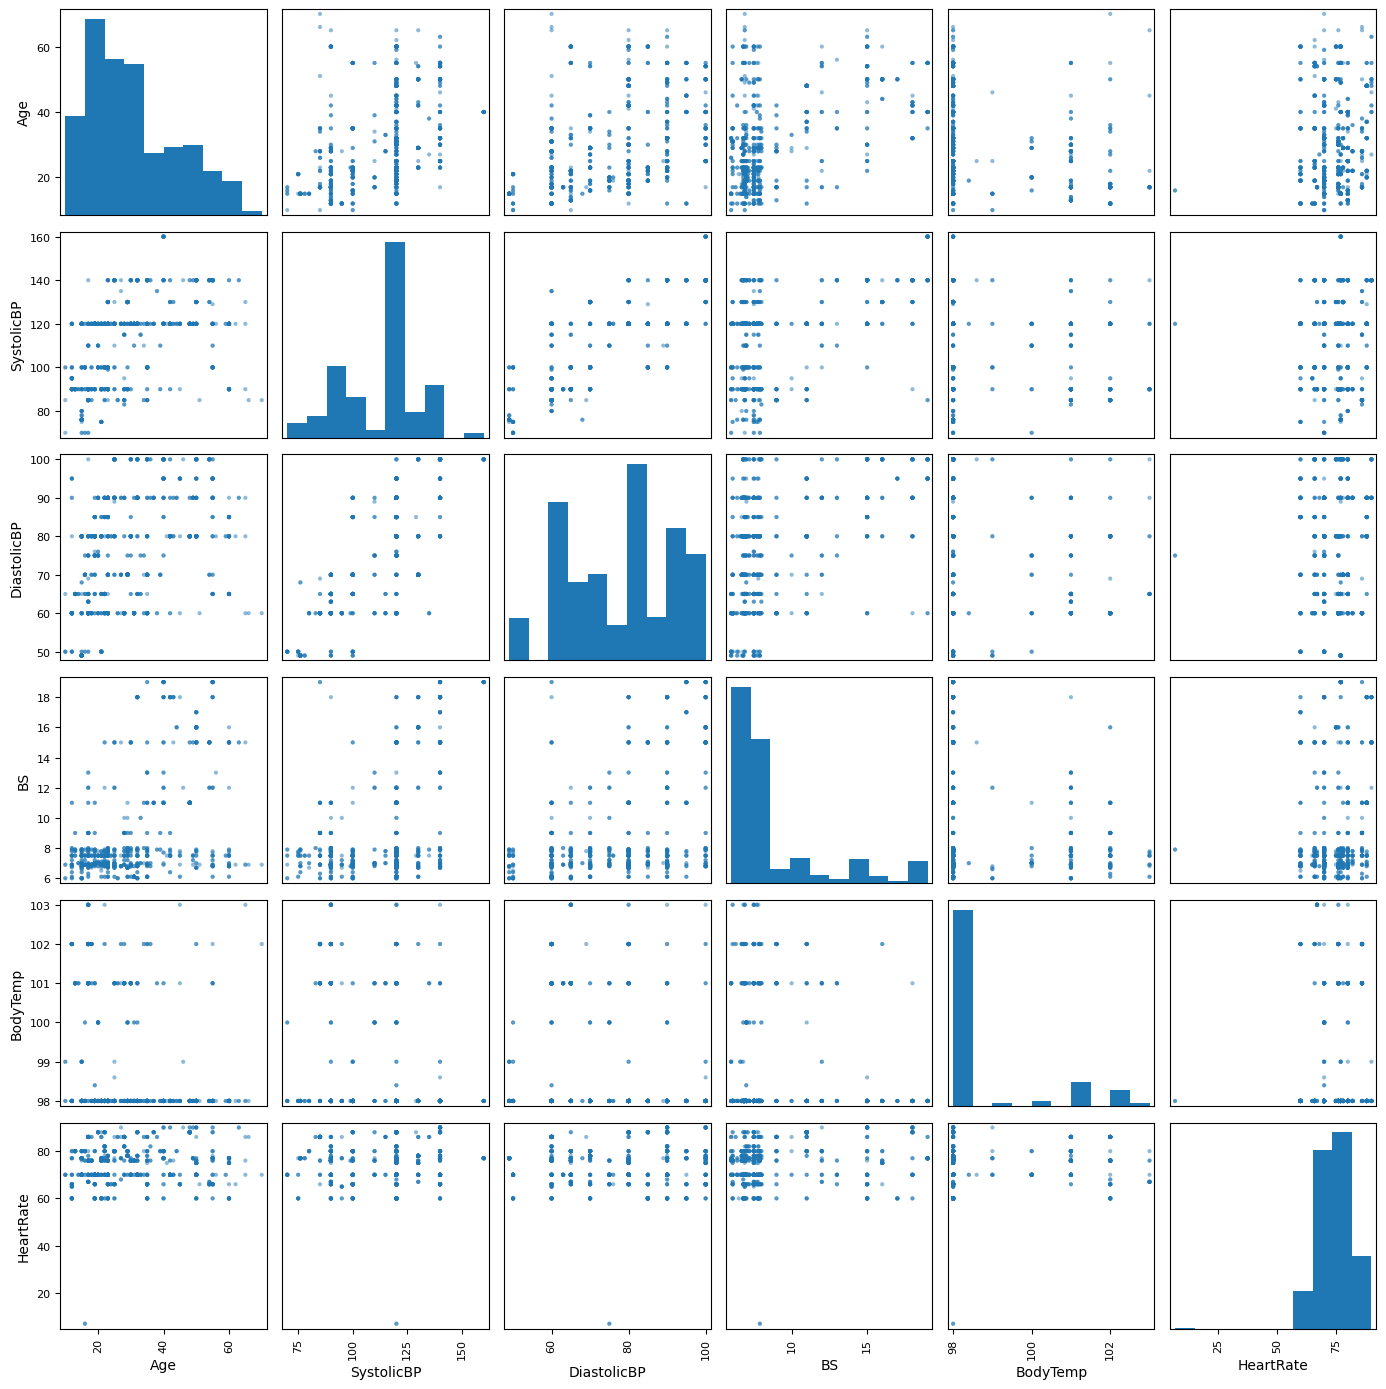

In [7]:
#Pair plots
numeric_df = df.select_dtypes(include=['float64', 'int64'])
scatterplotmatrix(numeric_df,
                  figsize=(14, 14),  
                  alpha=0.5)

plt.tight_layout()
plt.show()

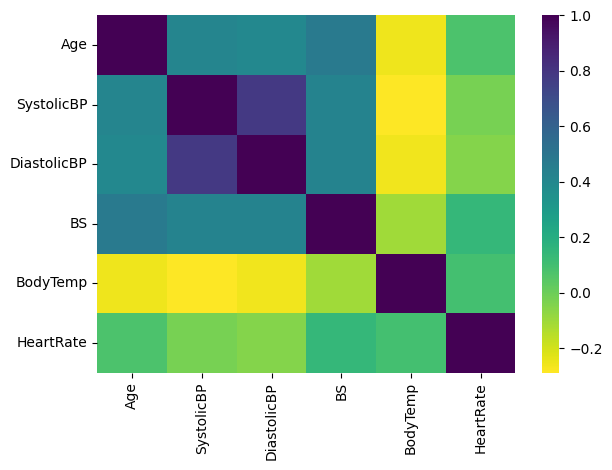

In [8]:
#Heat Map
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
cm = df[numeric_features].corr()
hm = heatmap(cm, cmap='viridis_r')

plt.tight_layout()
plt.show()

--- Model Performance Metrics ---
Accuracy: 64.50%
Weighted F1 Score: 0.63

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   high risk       0.82      0.73      0.77       136
    low risk       0.62      0.84      0.72       203
    mid risk       0.50      0.34      0.41       168

    accuracy                           0.64       507
   macro avg       0.65      0.64      0.63       507
weighted avg       0.64      0.64      0.63       507



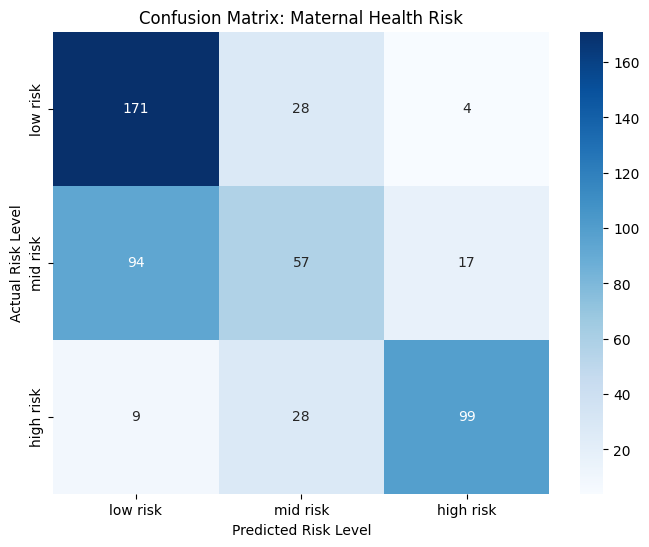

In [15]:
# Setting target and features
X = df.drop(['RiskLevel'], axis=1)
y = df['RiskLevel']

# All features are numeric
numeric_features = X.columns

# Split 50/50
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# Preprocessing pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features)
])

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

# Fit model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Metrics
print("--- Model Performance Metrics ---")
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Weighted F1 Score: {f1:.2f}")

# Classification report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_mat = confusion_matrix(
    y_test, y_pred,
    labels=["low risk", "mid risk", "high risk"]
)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["low risk", "mid risk", "high risk"],
            yticklabels=["low risk", "mid risk", "high risk"])

plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.title('Confusion Matrix: Maternal Health Risk')
plt.show()

In [16]:
print(f"Training Accuracy: {pipeline.score(X_train, y_train)*100:.2f}%")

Training Accuracy: 61.93%


In a medical diagnostic tool False Negatives are much worse than false Positives. A false postive is where a healthy person is misplaced as high risk, which cuuses some unnecessary panic but no strong issues. On the other hand a False Negative is highly dangerous as someone at high risk may be labeled as healthy and not get the help they need to get better. Therefore we want a high recall number: ensuring nearly all patients in need of urgent care are correctly flagged. 

For a medical project 64.5% accuracy is too low.We want to look at the categories individually. The good thing is that we see a high precision for the "high risk" group at .82, so when the model flags a patient as high risk it is correct 82% of the time. This is good because we wont be wrong too often causing unnecessary panic.

The bad thig we see is the missing "High risk" patients, that weren't detected and they should have been. The Recall for high risk was .73 which means we missed 27% of the actual high risk patients, labeling the mas mid risk or low risk. That is not good because thats 27 of 100 people in a real clinic who need urgent help but weren't flagged by the system. So we need to fix that.

Our struggle is that the model is struggling with the "mid Risk" category, the recall is only .34. It is likely that the physical markers for midrisk overlap too much with both ihgh and low risk. Therefore a simple Logistic Regression isnt smart enough to see the difference and we will need to try a more complex model. 

### Tree Based Method

In [17]:
#First checking for class imbalance
print(df['RiskLevel'].value_counts())

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


It looks like there is not a serious imbalance, so we do not need to worry about fixing an imbalanced dataset.

Best Parameters: {'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 20, 'classifier__n_estimators': 100}
Best CV Weighted F1: 0.8256396464082334
[[66 15  0]
 [ 7 58  2]
 [ 1  2 52]]
Train Accuracy: 92.48%
Test Accuracy: 86.70%
Train Error Rate: 7.52%
Test Error Rate: 13.30%
Test Weighted F1 Score: 0.87
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.89      0.81      0.85        81
    mid risk       0.77      0.87      0.82        67

    accuracy                           0.87       203
   macro avg       0.88      0.88      0.87       203
weighted avg       0.87      0.87      0.87       203



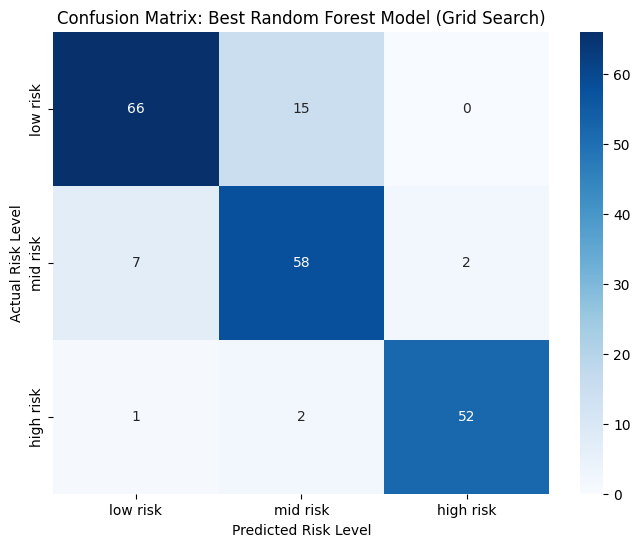

In [ ]:
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# All features are numeric
numeric_features = X.columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ]
)

# Creating the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Parameter grid
param_grid = [
    {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [5, 10, 20, 30]
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 10, 20]
    },
    {
        'classifier': [BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)],
        'classifier__n_estimators': [10, 50, 100]
    }
]

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best model info
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best CV Weighted F1:", best_score)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

# Metrics
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
error_rate_train = 1 - accuracy_train
error_rate_test = 1 - accuracy_test
f1_score_test = f1_score(y_test, y_pred_test, average='weighted')

# Confusion Matrix
conf_matrix = confusion_matrix(
    y_test, y_pred_test,
    labels=["low risk", "mid risk", "high risk"]
)
print(conf_matrix)

print(f"Train Accuracy: {accuracy_train*100:.2f}%")
print(f"Test Accuracy: {accuracy_test*100:.2f}%")
print(f"Train Error Rate: {error_rate_train*100:.2f}%")
print(f"Test Error Rate: {error_rate_test*100:.2f}%")
print(f"Test Weighted F1 Score: {f1_score_test:.2f}")

print(classification_report(y_test, y_pred_test))

#Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=["low risk", "mid risk", "high risk"],
    yticklabels=["low risk", "mid risk", "high risk"]
)

plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
# Updated title to reflect it's the optimized model
plt.title('Confusion Matrix: Best Random Forest Model (Grid Search)') 
plt.show()


This model worked much better because Logistic Regression tries to draw a single straight line through data. Random Forest uses decision trees that can handle complex rules (e.g. If blood sugar is over X and age is over Y, then it's Mid Risk). This allowed the model to finally see the patterns defining the middle category.

Maternal health factors rarely follow a straight line. For example, high blood sugar might be 'normal' for one age group but 'high risk' for another. The Random Forest model succeeds here because it uses an ensemble of decision trees to capture these complex, non-linear interactions. It helps to understand each woman based off their characteristics for their specififc results to come to proper conclusions.

To avoid overfitting,where a model just memorizes the training data, we used StratifiedKFold cross-validation. This ensures that every time we tested the model during training, each fold had a fair representation of low, mid, and high-risk patients. Our GridSearchCV then automatically stress tested different tree depths and estimators to find the most reliable settings.

A confusion matrix is one of the most essential graphs for medical data as it helps us with our safety precautions greatly. The confusion matrix tells us what we need to know and visualizes it. The model almost never confuses "Low Risk" with "High Risk" (that 0 in the top right corner). When it does make a mistake, it usually just swaps Low for Mid or Mid for Low. In a hospital, that’s a much more forgivable error than missing a life-threatening high-risk case.

By achieving a 95% recall for the High Risk category, our model demonstrates high clinical sensitivity, and accomplishes our goal to have nearly all high risk patients correctly flagged. Our confusion matrix shows that the model rarely confuses high risk and low risk. Most of the minor errors occur between Low and Mid which isn't a big issue as these two categories are similar and have overlap, the important thing is that the High Risk markers remain distinct and highly detectable.